In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/processed/cleaned_supply_chain.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (180519, 51)


In [2]:
print(df.columns.tolist())

['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Id', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Product Card Id', 'Product Category Id', 'Product Image', 'Product Name', 'Product Price', 'Product Status', 'shipping date (DateOrders)', 'Shipping Mode', 'Order Year', 'Order Month', 'Order Day', 'Order Weekday']


In [3]:
print("Late Delivery Risk:")
print(df["Late_delivery_risk"].value_counts())

print("\nShipping Days:")
print(df[[
    "Days for shipping (real)",
    "Days for shipment (scheduled)"
]].describe())

Late Delivery Risk:
Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64

Shipping Days:
       Days for shipping (real)  Days for shipment (scheduled)
count             180519.000000                  180519.000000
mean                   3.497654                       2.931847
std                    1.623722                       1.374449
min                    0.000000                       0.000000
25%                    2.000000                       2.000000
50%                    3.000000                       4.000000
75%                    5.000000                       4.000000
max                    6.000000                       4.000000


In [4]:
# Check missing values in important columns

important_columns = [
    "Late_delivery_risk",
    "Days for shipping (real)",
    "Days for shipment (scheduled)",
    "Shipping Mode",
    "Order Item Quantity",
    "Sales",
    "Product Price",
    "Market",
    "Order Region",
    "Category Name"
]

print(df[important_columns].isnull().sum())

Late_delivery_risk               0
Days for shipping (real)         0
Days for shipment (scheduled)    0
Shipping Mode                    0
Order Item Quantity              0
Sales                            0
Product Price                    0
Market                           0
Order Region                     0
Category Name                    0
dtype: int64


In [5]:
# Calculate actual shipping delay

df["Shipping_Delay_Days"] = (
    df["Days for shipping (real)"] -
    df["Days for shipment (scheduled)"]
)

print(df["Shipping_Delay_Days"].describe())

print("\nDelay distribution:")
print(df["Shipping_Delay_Days"].value_counts().sort_index().head(20))

count    180519.000000
mean          0.565807
std           1.490966
min          -2.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           4.000000
Name: Shipping_Delay_Days, dtype: float64

Delay distribution:
Shipping_Delay_Days
-2    21666
-1    21700
 0    33753
 1    60647
 2    28718
 3     7052
 4     6983
Name: count, dtype: int64


In [6]:
df["Shipping_Delay_Days"].describe()

count    180519.000000
mean          0.565807
std           1.490966
min          -2.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           4.000000
Name: Shipping_Delay_Days, dtype: float64

In [7]:
# Create the target variable for delay prediction

df["Delayed"] = (df["Shipping_Delay_Days"] > 0).astype(int)

print("Delay classification:")
print(df["Delayed"].value_counts())

print("\nDelay percentage:")
print(df["Delayed"].value_counts(normalize=True) * 100)

Delay classification:
Delayed
1    103400
0     77119
Name: count, dtype: int64

Delay percentage:
Delayed
1    57.279289
0    42.720711
Name: proportion, dtype: float64


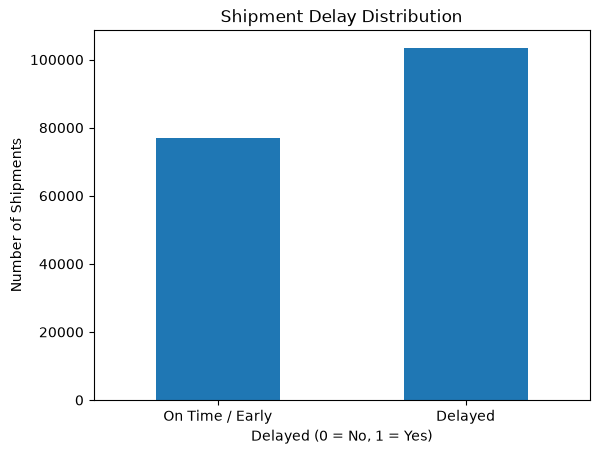

In [8]:
import matplotlib.pyplot as plt

df["Delayed"].value_counts().sort_index().plot(kind="bar")

plt.title("Shipment Delay Distribution")
plt.xlabel("Delayed (0 = No, 1 = Yes)")
plt.ylabel("Number of Shipments")
plt.xticks([0, 1], ["On Time / Early", "Delayed"], rotation=0)
plt.show()

In [9]:
# Display all columns in our dataset

for i, col in enumerate(df.columns):
    print(i, col)

0 Type
1 Days for shipping (real)
2 Days for shipment (scheduled)
3 Benefit per order
4 Sales per customer
5 Delivery Status
6 Late_delivery_risk
7 Category Id
8 Category Name
9 Customer City
10 Customer Country
11 Customer Id
12 Customer Segment
13 Customer State
14 Customer Street
15 Customer Zipcode
16 Department Id
17 Department Name
18 Latitude
19 Longitude
20 Market
21 Order City
22 Order Country
23 Order Customer Id
24 order date (DateOrders)
25 Order Id
26 Order Item Cardprod Id
27 Order Item Discount
28 Order Item Discount Rate
29 Order Item Id
30 Order Item Product Price
31 Order Item Profit Ratio
32 Order Item Quantity
33 Sales
34 Order Item Total
35 Order Profit Per Order
36 Order Region
37 Order State
38 Order Status
39 Product Card Id
40 Product Category Id
41 Product Image
42 Product Name
43 Product Price
44 Product Status
45 shipping date (DateOrders)
46 Shipping Mode
47 Order Year
48 Order Month
49 Order Day
50 Order Weekday
51 Shipping_Delay_Days
52 Delayed
